# ALMA SODA Cutout Examples

This notebook imports `get_cutout` from the local `get_cutout.py` script and shows three common examples:

- a continuum cutout shown as an image
- HNCO moment-map cutouts shown as images
- an HNCO cube cutout reduced to a mean spectrum

Run this notebook from the same directory as `get_cutout.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy import constants as const
from astropy import units as u
from astropy.io import fits

from get_cutout import get_cutout

In [2]:
GLON = 0.0
GLAT = 0.0
RADIUS_ARCSEC = 20
VMIN = -100 
VMAX = 100

OUTDIR = Path("example_outputs")
OUTDIR.mkdir(exist_ok=True)

CONTINUUM_ID = "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m.cont.93.7GHz_bw4.7GHz.pbcor.fits"
HNCO_MOM0_ID = "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HNCO.integrated_intensity.fits"
HNCO_PEAK_ID = "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HNCO.peak_intensity.fits"
H40A_CUBE_ID = "group.uid___A001_X1590_X30a9.lp_slongmore.cmz_mosaic.icrs.12m7mTP.HNCO.cube.pbcor.fits"

In [3]:
def download_if_needed(dataset_id, outfile, vmin=None, vmax=None):
    outfile = Path(outfile)
    if outfile.exists():
        print(f"Using existing {outfile}")
        return outfile

    get_cutout(
        dataset_id,
        GLON,
        GLAT,
        RADIUS_ARCSEC,
        vmin=vmin,
        vmax=vmax,
        outfile=str(outfile),
    )
    return outfile


def image_plane(path):
    data = np.squeeze(fits.getdata(path))
    if data.ndim == 2:
        return data
    if data.ndim == 3:
        return np.nanmean(data, axis=0)
    raise ValueError(f"Expected a 2D image or 3D cube-like array, got shape {data.shape}")


def show_image(path, title, ax=None, cmap="inferno"):
    image = image_plane(path)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    finite = np.isfinite(image)
    vmin, vmax = np.nanpercentile(image[finite], [1, 99]) if finite.any() else (None, None)
    im = ax.imshow(image, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Pixel")
    ax.set_ylabel("Pixel")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax


def mean_spectrum(path):
    data = np.squeeze(fits.getdata(path))
    header = fits.getheader(path)
    if data.ndim != 3:
        raise ValueError(f"Expected a 3D cube after squeezing, got shape {data.shape}")

    spectrum = np.nanmean(data, axis=(1, 2))
    channels = np.arange(spectrum.size) + 1

    unit = u.Unit(header.get("CUNIT3", "Hz").strip() or "Hz")
    frequency = (header["CRVAL3"] + (channels - header["CRPIX3"]) * header["CDELT3"]) * unit
    rest_frequency = header.get("RESTFRQ", header.get("RESTFREQ")) * u.Hz
    velocity = ((1 - frequency.to(u.Hz) / rest_frequency) * const.c).to(u.km / u.s)
    return velocity.value, spectrum

## Continuum Image Cutout

Using existing example_outputs/continuum_20arcsec.fits


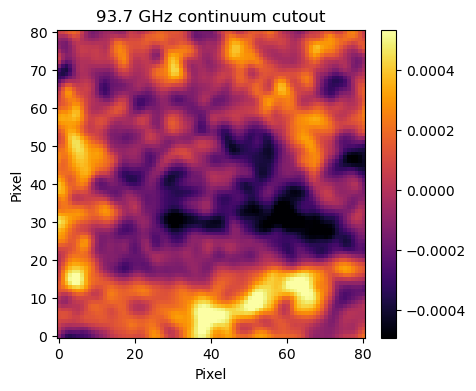

In [4]:
continuum_path = download_if_needed(
    CONTINUUM_ID,
    OUTDIR / "continuum_20arcsec.fits",
)

show_image(continuum_path, "93.7 GHz continuum cutout")
plt.show()

## HNCO Moment-Map Cutouts

Using existing example_outputs/hnco_integrated_intensity_20arcsec.fits
Using existing example_outputs/hnco_peak_intensity_20arcsec.fits


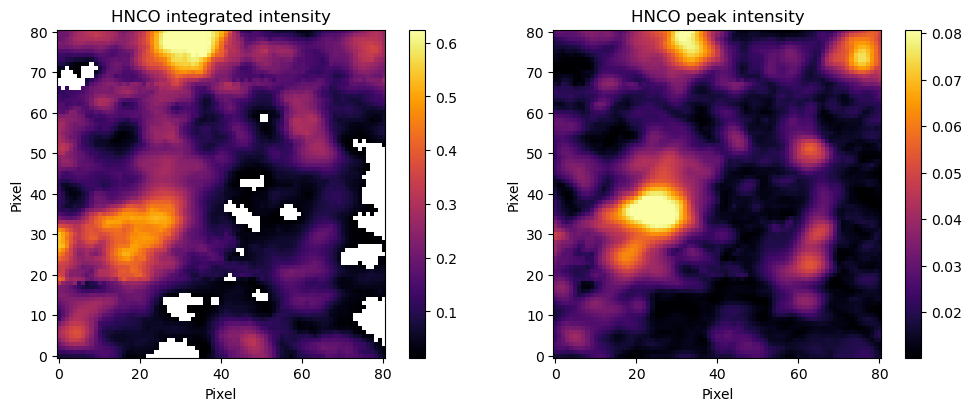

In [5]:
hnco_mom0_path = download_if_needed(
    HNCO_MOM0_ID,
    OUTDIR / "hnco_integrated_intensity_20arcsec.fits",
)
hnco_peak_path = download_if_needed(
    HNCO_PEAK_ID,
    OUTDIR / "hnco_peak_intensity_20arcsec.fits",
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
show_image(hnco_mom0_path, "HNCO integrated intensity", ax=axes[0])
show_image(hnco_peak_path, "HNCO peak intensity", ax=axes[1])
plt.show()

## HNCO Cube Cutout And Mean Spectrum

Using existing example_outputs/HNCO_cube_20arcsec_m100_p100kms.fits


/var/folders/3y/cmsgt3_x7x72bbs__zhy_q6h0008wr/T/ipykernel_19220/4219587784.py:49: RuntimeWarning: Mean of empty slice
  spectrum = np.nanmean(data, axis=(1, 2))


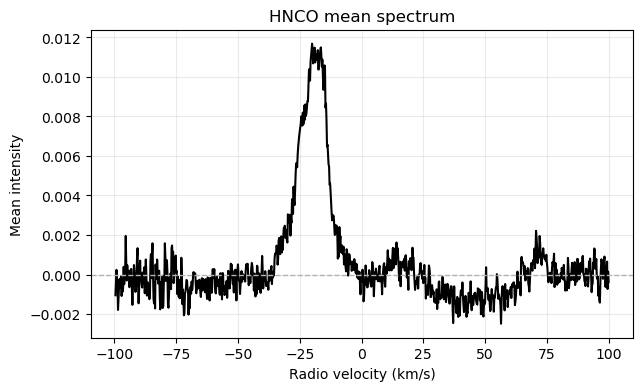

In [6]:
cube_path = download_if_needed(
    H40A_CUBE_ID,
    OUTDIR / "HNCO_cube_20arcsec_m100_p100kms.fits",
    vmin=VMIN,
    vmax=VMAX,
)

velocity, spectrum = mean_spectrum(cube_path)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(velocity, spectrum, color="black", lw=1.5)
ax.axhline(0, color="0.7", lw=1, ls="--")
ax.set_xlabel("Radio velocity (km/s)")
ax.set_ylabel("Mean intensity")
ax.set_title("HNCO mean spectrum")
ax.grid(alpha=0.25)
plt.show()